In [ ]:
#*****************************************************************
# Date:         February, 2026
# Author:       Opeoluwa Adebayo, ooadebayo@mun.ca
# Institution:  Memorial University of Newfoundland, St. John's, NL
#*****************************************************************

In [80]:
# Import the necessary libraries
import numpy as np
import control as ct
from scipy import signal
import matplotlib.pyplot as plt
import seaborn as sns       # Optional
import warnings

# Suppress runtime warning
warnings.filterwarnings("ignore")

In [81]:
# Set Seaborn style for plots
sns.set_theme()

In [82]:
#****** State Space Model **************

# Define the state space matrices for the system
A = np.array([
    [-0.0085, 0, 0.0085],
    [0, -0.0195, 0.0084],
    [0.0085, 0.0084, -0.0169]
])

B = np.array([
    [0.0065, 0],
    [0, 0.0065],
    [0, 0]
])

C = np.eye(3)       # 3 x 3 identity matrix

D = np.zeros((3, 2))  # 3 x 2 zero matrix

# Create a state space model for the tank system
sys_fault_free = ct.ss(A, B, C, D, name="three tank sys", states=["h1", "h2", "h3"],
            inputs=["Q1", "Q2"], outputs=["h1", "h2", "h3"])

print(sys_fault_free)

<StateSpace>: three tank sys
Inputs (2): ['Q1', 'Q2']
Outputs (3): ['h1', 'h2', 'h3']
States (3): ['h1', 'h2', 'h3']

A = [[-0.0085  0.      0.0085]
     [ 0.     -0.0195  0.0084]
     [ 0.0085  0.0084 -0.0169]]

B = [[0.0065 0.    ]
     [0.     0.0065]
     [0.     0.    ]]

C = [[1. 0. 0.]
     [0. 1. 0.]
     [0. 0. 1.]]

D = [[0. 0.]
     [0. 0.]
     [0. 0.]]


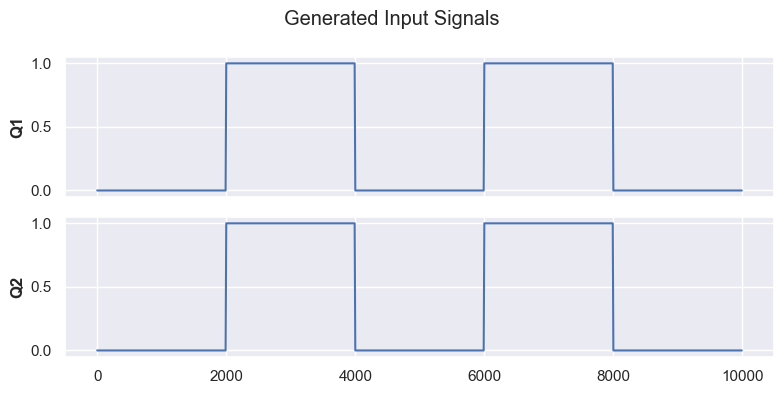

In [83]:
#********* Generate Square Input Signals **********

# Signal parameters
period = 4000
t_final = 10000     # total simulation time
Ts = 10             # sampling time

# Time vector
t = np.arange(0, t_final, Ts)

# Frequency
f = 1 / period

# Square wave (±0) for Q1 and Q2 
Q1 = 0.5*(1-signal.square(2 * np.pi * f * t))
Q2 = 0.5*(1-signal.square(2 * np.pi * f * t))

# Plot of the generated signals
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax = ax.flatten()

# plot of Q1
ax[0].plot(t, Q1)
ax[0].set_ylabel("Q1", weight="demibold")

# plot of Q2
ax[1].plot(t, Q2)
ax[1].set_ylabel("Q2", weight="demibold")

fig.suptitle("Generated Input Signals")
fig.tight_layout()

plt.show()

In [84]:
#********** Additive Faults ******************
f1 = 0 * np.ones((len(t), 1)).flatten()     # Additive fault in sensor measuring h1
f2 = 0 * np.ones((len(t), 1)).flatten()     # Additive fault in sensor measuring h2
f3 = 0 * np.ones((len(t), 1)).flatten()     # Additive fault in sensor measuring h3
f4 = 0 * np.ones((len(t), 1)).flatten()     # Additive fault in pump 1
f5 = 0 * np.ones((len(t), 1)).flatten()     # Additive fault in pump 2

# Stack the inputs (Q1, Q2) and the additive fault signals
u = np.vstack((Q1, Q2))
u_line = np.vstack((u, f1, f2, f3, f4, f5))

In [ ]:
#******** State Space & Multiplicative Fault Matrices ****************
A1 = np.array([
    [-0.0214, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
])

A2 = np.array([
    [0, 0, 0],
    [0, -0.0371, 0],
    [0, 0, 0]
])

A3 = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, -0.0262]
])


A4 = np.array([
    [-0.0085, 0, 0.0085],
    [0, 0, 0],
    [0.0085, 0, -0.0085]
])


A5 = np.array([
    [0, 0, 0],
    [0, -0.0111, 0],
    [0, 0, 0]
])


A6 = np.array([
    [0, 0, 0],
    [0, -0.0084, 0.0084],
    [0, 0.0084, -0.0084]
])


Ai = [A1, A2, A3, A4, A5, A6]

# Multiplicative fault size
theta_Ai = [0.2, 0, 0, 0, 0, 0]        # Modify this to simulate multiplicative fault

# delta_A = SUM of theta_Ai * Ai for i=1:6
dA = np.zeros((3, 3))
for idx in range(len(theta_Ai)):
    dA += theta_Ai[idx]* Ai[idx]


# Modified A (to accommodate multiplicative faults)
A_line = A + dA


# Modified B (to accommodate the additive faults)
Ef = np.hstack((np.zeros((3, 3)), B))
B_line = np.hstack((B, Ef))

C_line = C

# Modified D (to accomodate the additive faults)
Ff = np.hstack((np.eye(3), D))
D_line = np.hstack((D, Ff))


# Faulty state space matrix
sys_faulty = ct.ss(A_line, B_line, C_line, D_line)

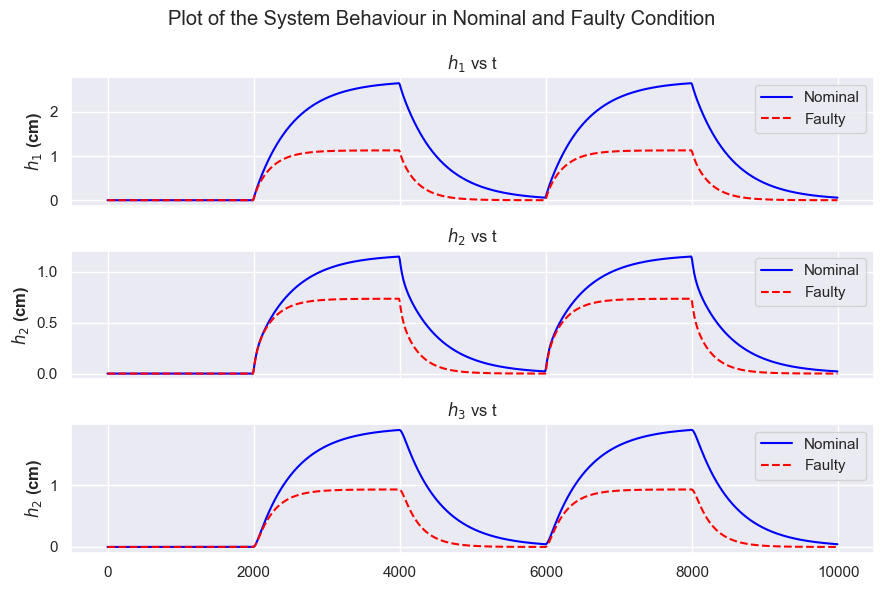

In [ ]:
# Method 1: We can use "forced_response" to simulate the dynamic response. It is similar to MATLAB's lsim
response_free = ct.forced_response(sys_fault_free, t, u)
response_faulty = ct.forced_response(sys_faulty, t, u_line)

# Extract time and output for plotting
y_free = response_free.outputs   # dimension: y_free[num_outputs, time]
y_faulty = response_faulty.outputs   # dimension: y_faultynum_outputs, time]

# Plot of the dynamic response
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
ax = ax.flatten()

# h1 response
ax[0].plot(t, y_free[0, :], color='blue', label="Nominal")
ax[0].plot(t, y_faulty[0, :], color="red", linestyle='--', label="Faulty")
ax[0].set_ylabel(r'$h_1$ (cm)', weight='demibold')
ax[0].set_title(r'$h_1$ vs t')
ax[0].legend()

# h2 response
ax[1].plot(t, y_free[1, :], color='blue', label="Nominal")
ax[1].plot(t, y_faulty[1, :], color="red", linestyle='--', label="Faulty")
ax[1].set_ylabel(r'$h_2$ (cm)', weight='demibold')
ax[1].set_title(r'$h_2$ vs t')
ax[1].legend()

# h3 response
ax[2].plot(t, y_free[2, :], color='blue', label="Nominal")
ax[2].plot(t, y_faulty[2, :], color="red", linestyle='--', label="Faulty")
ax[2].set_ylabel(r'$h_2$ (cm)', weight='demibold')
ax[2].set_title(r'$h_3$ vs t')
ax[2].legend()

fig.suptitle("Plot of the System Behaviour in Nominal and Faulty Condition")
fig.tight_layout()

plt.show()

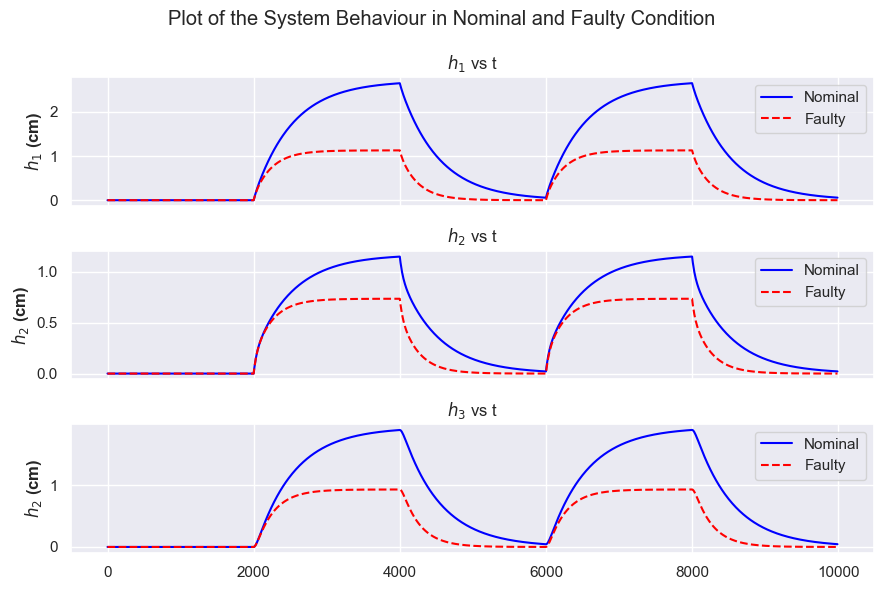

In [ ]:
# Method 2: We can discretize the state space and simulate by iterating the discrete state equations
sysd_free = ct.sample_system(sys_fault_free, Ts, method="zoh")  # Nominal discrete state space model
sysd_faulty = ct.sample_system(sys_faulty, Ts, method="zoh")    # Faulty discrete state space model

# Extract the necessary discretized matrices
A_d_free = sysd_free.A
B_d_free = sysd_free.B
C_d_free= sysd_free.C
D_d_free = sysd_free.D

A_d_faulty = sysd_faulty.A
B_d_faulty = sysd_faulty.B
C_d_faulty= sysd_faulty.C
D_d_faulty = sysd_faulty.D

# Parameters
N = len(t)       # number of samples
num_states = A_d_free.shape[0]
num_outputs = C_d_free.shape[0]

# Initialize the state and output vector
x_free = np.zeros((num_states, N+1))
y_free = np.zeros((num_states, N))

x_faulty = np.zeros((num_states, N+1))
y_faulty = np.zeros((num_states, N))


# Loop through the time step
for k in range(N):
    # Fault free model
    y_free[:,k] = C_d_free @ x_free[:,k] + D_d_free @ u[:, k]
    x_free[:, k+1] = A_d_free @ x_free[:, k] + B_d_free @ u[:, k]

    # Faulty model
    y_faulty[:,k] = C_d_faulty @ x_faulty[:,k] + D_d_faulty @ u_line[:, k]
    x_faulty[:, k+1] = A_d_faulty @ x_faulty[:, k] + B_d_faulty @ u_line[:, k]


# Plot of the dynamic response
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
ax = ax.flatten()

# h1 response
ax[0].plot(t, y_free[0, :], color='blue', label="Nominal")
ax[0].plot(t, y_faulty[0, :], color="red", linestyle='--', label="Faulty")
ax[0].set_ylabel(r'$h_1$ (cm)', weight='demibold')
ax[0].set_title(r'$h_1$ vs t')
ax[0].legend()

# h2 response
ax[1].plot(t, y_free[1, :], color='blue', label="Nominal")
ax[1].plot(t, y_faulty[1, :], color="red", linestyle='--', label="Faulty")
ax[1].set_ylabel(r'$h_2$ (cm)', weight='demibold')
ax[1].set_title(r'$h_2$ vs t')
ax[1].legend()

# h3 response
ax[2].plot(t, y_free[2, :], color='blue', label="Nominal")
ax[2].plot(t, y_faulty[2, :], color="red", linestyle='--', label="Faulty")
ax[2].set_ylabel(r'$h_2$ (cm)', weight='demibold')
ax[2].set_title(r'$h_3$ vs t')
ax[2].legend()

fig.suptitle("Plot of the System Behaviour in Nominal and Faulty Condition")
fig.tight_layout()

plt.show()